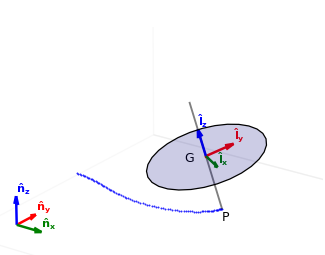

The figure above shows a top of radius $\text{r}$ and mass $\text{m}$ whose bottom stem, unlike Lagrange top, can move on the floor. The distance between the top's mass center $\text{G}$ and its stem's bottom $\text{P}$ is $\text{d}$. The top's rotation will be described with reference frames $\text{Y}$, $\text{L}$ and $\text{R}$ associated with each Euler angle ($\psi, \theta, \phi$) following the ZXZ convention. 

The top has principal moment of inertia $I_3$​ about its symetrical axis and $I_1$ about the axes in a plane perpendicular to the symmetrical axis. The cell [1] provides necessary Python packages and the cell [2] defines SymPy symbols, reference frames and objects for this simulation. 

In [1]:
%matplotlib widget
from sympy import symbols, lambdify, solve, cos, sin
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
from sympy.physics.mechanics import ReferenceFrame, Point, inertia
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.animation import FuncAnimation
init_vprinting()

In [2]:
# Symbols for variables and parameters 
m, r, d, g, t = symbols('m r d g t') # top's mass, radius, distance between mass center and bottom end, gravity acceleration, time
k_n, k_f, mu = symbols('k_n k_f mu') # normal reactional force, frictional force, coefficient of friction
I_1, I_3, omega_c = symbols('I_1 I_3 omega_c' ) #principal moments of inertia, constant angular velocity

# Euler angles and thier 1st order time derivatives
psi, theta, phi= dynamicsymbols('psi theta phi')
psi_dot = dynamicsymbols('psi',1) 
theta_dot = dynamicsymbols('theta',1) 
phi_dot = dynamicsymbols('phi',1) 
psi_ddot = dynamicsymbols('psi',2) 
theta_ddot = dynamicsymbols('theta',2) 

# angular velocities of rotating frames
omega_1, omega_2, omega_3 = dynamicsymbols('omega_1 omega_2 omega_3')
omicron_1, omicron_2, omicron_3 = dynamicsymbols('omicron_1 omicron_2 omicron_3')

# mass center's horizontal position 
x1, x2, x3= dynamicsymbols('x1 x2 x3')
x1_dot = dynamicsymbols('x1', 1)
x2_dot = dynamicsymbols('x2', 1)
x3_dot = dynamicsymbols('x3', 1)


# mass center's velocity
v1, v2, v3 = dynamicsymbols('v_1 v_2 v_3')
v1_dot = dynamicsymbols('v_1', 1)
v2_dot =  dynamicsymbols('v_2', 1)
#vz_dot =  dynamicsymbols('v_z', 1)

# define reference frames (Euler 313)
N = ReferenceFrame('N') # inertia frame
Y = N.orientnew('Y', 'Axis', (psi, N.z)) 
L = Y.orientnew('L','Axis', (theta,Y.x)) 
R = L.orientnew('R', 'Axis', (phi,L.z))

The angular velocity of the frame  $\text{L}$ observed from the space-fixed frame $\text{N}$ is denoted as $^N\boldsymbol{\Omega}^L$ and that of the frame $\text{R}$ as $^N\boldsymbol{\Omega}^R$. Both will be expressed with the $\text{L}$-frame basis vectors:

$$
\begin{align}
^N\boldsymbol{\Omega}^L =& \omicron_1\boldsymbol{\hat{l}_x} + \omicron_2\boldsymbol{\hat{l}_y} + \omicron_3\boldsymbol{\hat{l}_z} \tag{1a}\\
^N\boldsymbol{\Omega}^R =& \omega_1\boldsymbol{\hat{l}_x} + \omega_2\boldsymbol{\hat{l}_y} + \omega_3\boldsymbol{\hat{l}_z} \tag{2a}
\end{align}
$$
and also described in terms of Euler angles ($\psi, \theta, \phi$) as below:
$$
\begin{align}
^N\boldsymbol{\Omega}^L =& \dot{\theta}\boldsymbol{\hat{l}_x} + \sin \theta \dot{\psi} \boldsymbol{\hat{l}_y} + \cos\theta\dot{\psi} \boldsymbol{\hat{l}_z}\tag{1b}\\
^N\boldsymbol{\Omega}^R =& \dot{\theta}\boldsymbol{\hat{l}_x} + \sin \theta \dot{\psi} \boldsymbol{\hat{l}_y} + (\cos\theta\dot{\psi}+\dot{\phi}) \boldsymbol{\hat{l}_z}\tag{2b}
\end{align}
$$
Comparing the equations (1a) and (2b) we have:
$$
\begin{align}
\omega_1=\omicron_1 = \dot{\theta}\\
\omega_2 = \omicron_2 = \sin \theta \dot{\psi} \tag{3}\\
\omega_3= \omicron_3+\dot{\phi}
\end{align}
$$
and can rewrite (1a) as below:
$$
^N\boldsymbol{\Omega}^L = \omega_1\boldsymbol{\hat{l}_x} + \omega_2\boldsymbol{\hat{l}_y} + \omicron_3\boldsymbol{\hat{l}_z} \tag{1c}
$$

Euler's equations of rotational motion is given by:
$$
\frac{^N{d{\boldsymbol{H}}}}{dt}=\frac{^L{d{\boldsymbol{H}}}}{dt} + ^N\boldsymbol{\Omega}^L \times \boldsymbol{H} = \boldsymbol{\tau} \tag{4}
$$
where $\boldsymbol{H}$ is angular momentum and $\boldsymbol{\tau}$ is torque, both about the mass center. If we defince $I_1$, $I_3$ as the principal moments of inertia, then $\boldsymbol{H}$ is written as: 
$$
\boldsymbol{H} = I_1\omega_1\boldsymbol{\hat{l}_x} +I_1\omega_2\boldsymbol{\hat{l}_y}+I_3\omega_3\boldsymbol{\hat{l}_z} \tag{5}
$$
and time derivative of angular momentum in the inertial frame is 
$$
\frac{^N{d{\boldsymbol{H}}}}{dt} =(I_1\dot{\omega}_1+(I_3 \omega_3-I_1 \omicron_3))\omega_2\boldsymbol{\hat{l}_x} +(I_1\dot{\omega}_2\boldsymbol+(I_1\omicron_3-I_3\omega_3)\omega_1){\hat{l}_y}+I_3\dot{\omega}_3\boldsymbol{\hat{l}_z}\tag{6}
$$

In [3]:
# define the angular velocities of both L and R frames 
N_w_L=omega_1*L.x+omega_2*L.y+omicron_3*L.z
N_w_R=omega_1*L.x+omega_2*L.y+omega_3*L.z
# angular momentum of the top
I=inertia(L, I_1, I_1, I_3)
H_ang_momt = I.dot(N_w_R).express(L)
# time derivative of angular momentum w.r.t the inertial frame 
eq_h =H_ang_momt.dt(L)+N_w_L.cross(H_ang_momt)
eq_h_mtrx=eq_h.to_matrix(L)
eq_h_mtrx

⎡-I₁⋅ω₂⋅ο₃ + I₁⋅ω₁̇ + I₃⋅ω₂⋅ω₃⎤
⎢                            ⎥
⎢I₁⋅ω₁⋅ο₃ + I₁⋅ω₂̇ - I₃⋅ω₁⋅ω₃ ⎥
⎢                            ⎥
⎣           I₃⋅ω₃̇            ⎦

In [4]:
# angular velocities of L and R frames to be expressed in the Euler angles
eu_ang=(N_w_R-R.ang_vel_in(N)).to_matrix(L)
eu_ang_rpl = solve([eu_ang[0], eu_ang[1], eu_ang[2]],(omega_1, omega_2, omega_3))
eu_ang_rpl[omicron_3] = cos(theta)*psi_dot

The external force $\boldsymbol{F}_P$ exerted on the contact point consists of a normal reactional force $\boldsymbol{K}_n$ and frictional one $\boldsymbol{K}_f$. The torque is given by:
$$
\boldsymbol{\tau} = -d\boldsymbol{\hat{l}_z}\times(\boldsymbol{K}_n+\boldsymbol{K}_f)\tag{7}\\
$$
Here we assume viscous friction is exerted on the bottome end of the top which is propotional with the $\mu$ to its velocity $\boldsymbol{V}_P$.
$$\boldsymbol{K}_f=\,-\mu\,\boldsymbol{V}_P\tag{8}$$

If we express the mass center's velocity as $\boldsymbol{V}_G=v_1\boldsymbol{\hat{n}_x}+v_2\boldsymbol{\hat{n}_y} + v_3 \boldsymbol{\hat{n}_z}$, then using(1b) $\boldsymbol{V}_P$ is calculated as:
$$
\begin{align}
\boldsymbol{V}_P =&\, \boldsymbol{V}_{G}+^N\boldsymbol{\Omega}^L \times (-d)\boldsymbol{\hat{l}_z}\\
=& v_1\boldsymbol{\hat{n}_x}+v_2\boldsymbol{\hat{n}_y}+v_3\boldsymbol{\hat{n}_z}-d\sin\theta\,\dot{\psi}\boldsymbol{\hat{l}_x}+d\dot{\theta} \boldsymbol{\hat{l}_y}\tag{9}\\
\end{align}
$$
The point $\text{P}$ moves on the horizontal surface, thus $\boldsymbol{V}_P$ does not have a vertical component. With this constraint $\boldsymbol{V}_P\cdot \boldsymbol{\hat{n}}_z=0$ on (9), we have 
$$v_3=-d\dot{\theta}\sin\theta \tag{10}$$
then
$$
\boldsymbol{V}_P = (v_1-d\sin\psi\cos\theta\dot{\theta}-d\cos\psi\sin\theta\dot{\psi})\boldsymbol{\hat{n}_x}+(v_2+d\cos\psi\cos\theta\dot{\theta}-d\sin\psi\sin\theta\dot{\psi})\boldsymbol{\hat{n}_x}\tag{11}\\
$$

Notice that (11) does not include any contribution from the top's spinning angular velocity $\dot{\phi}$ about its symetrical axis. This is due to dimensional modelling of the spinning axis, thus the frictional forces exerted on the top at the contact point come from both nutation $\dot{\theta}$ and precession $\dot{\psi}$.

In [5]:
# mass center's velocity
VG=v1*N.x+v2*N.y+v3*N.z
# contact point's velocity
VP=VG+(L.ang_vel_in(N)).cross(-d*L.z)
# vertical component of the contact point' velocity
v3_eu=solve([VP.dot(N.z)],[v3])
VP_=VP.xreplace(v3_eu).express(N)
VP_

In [6]:
Kf=-mu*VP_
Kf.express(N)

The equations of translational motion are given by:
$$
m\frac{^N{d{\boldsymbol{V}_G}}}{dt} = \boldsymbol{F}-mg\boldsymbol{\hat{n}_z} \tag{12}\
$$
The normal reactional force $\boldsymbol{K}_n\,(=K_n\boldsymbol{\hat{n}}_z)$ can be obtained taking the dot product on both sides of (12) with $\boldsymbol{\hat{n}_z}$.
$$m\frac{^N{d{\boldsymbol{V}_G}}}{dt} \cdot \boldsymbol{\hat{n}_z} = \boldsymbol{F}\cdot\boldsymbol{\hat{n}_z}-mg\boldsymbol{\hat{n}_z}\cdot\boldsymbol{\hat{n}_z}$$
$$m\dot{v}_3=K_n-mg$$
$$K_n=m\dot{v}_3+mg$$ 
$\dot{v}_3$ can be obtained by taking time derivative of (10).
$$
\begin{align}
\boldsymbol{K}_n=&(m\dot{v}_3+mg) \boldsymbol{\hat{n}}_z\\
=& \{-md(\sin\theta\,\ddot{\theta}+\cos\theta\,\dot{\theta}^2)+mg\} \boldsymbol{\hat{n}}_z\tag{13}
\end{align}
$$
From (7), (8), (11) and (13) the torque can be obtained as a function of Euler angles and mass center velocity.
$$
\begin{align}
\boldsymbol{\tau} =& -d\boldsymbol{\hat{l}_z}\times((m\dot{v}_3+mg) \boldsymbol{\hat{n}}_z-\mu\,(v_1\boldsymbol{\hat{n}_x}+v_2\boldsymbol{\hat{n}_y}-d\sin\theta\,\dot{\psi}\boldsymbol{\hat{l}_x}))\\
=& \left[\{dgm-d^2m(\sin\theta\,\ddot{\theta}+\cos\theta\dot{\theta}^2)\}\sin\theta\, -d\mu(d\cos\theta\dot{\theta}-v_1\sin\psi+v_2\cos\psi)\cos\theta\right]\boldsymbol{\hat{l}_x}-d\mu(d\sin\theta\, \dot{\psi}-v_1\cos\psi-v_2\sin\psi)\, \boldsymbol{\hat{l}_y}\tag{14}\\
\end{align}
$$

In [7]:
# reactional force at the point P
Kn_=m*VG.dt(N).dot(N.z).simplify()+m*g
Kn=Kn_*N.z
Kn=Kn.xreplace(v3_eu)
Kn

⎛        ∂              ⎞    
⎜g⋅m + m⋅──(-d⋅sin(θ)⋅θ̇)⎟ n_z
⎝        ∂t             ⎠    

In [8]:
# deriving moment of force (torque)
Trq=(-d*L.z).cross(Kn+Kf).express(L).simplify()
Trq_m=Trq.to_matrix(L)
Trq_m

⎡  ⎛         2                       ⎛                        2⎞               ↪
⎢d⋅⎝- d⋅μ⋅cos (θ)⋅θ̇ + g⋅m⋅sin(θ) + m⋅⎝-d⋅sin(θ)⋅θ̈ - d⋅cos(θ)⋅θ̇ ⎠⋅sin(θ) + μ⋅v₁ ↪
⎢                                                                              ↪
⎢                                    d⋅μ⋅(-d⋅sin(θ)⋅ψ̇ + v₁⋅cos(ψ) + v₂⋅sin(ψ)) ↪
⎢                                                                              ↪
⎣                                                        0                     ↪

↪                                    ⎞⎤
↪ ⋅sin(ψ)⋅cos(θ) - μ⋅v₂⋅cos(ψ)⋅cos(θ)⎠⎥
↪                                     ⎥
↪                                     ⎥
↪                                     ⎥
↪                                     ⎦

Back to the Euler's equation we know from (6) and (14) $I_3\dot{\omega_3}=0$ and $\omega_3$ is constant. Replacing $\omega_3$ by $\omega_c$, the left-hand side of (6) becomes:
$$
\begin{align}
\frac{^N{d{\boldsymbol{H}}}}{dt} =&\{I_1\dot{\omega}_1+(I_3\omega_c-I_1 \omicron_3)\omega_2\}\boldsymbol{\hat{l}_x} +\{I_1\dot{\omega}_2\boldsymbol+(I_1\omicron_3-I_3\omega_c)\omega_1\}\boldsymbol{\hat{l}_y}\\
=&(I_1\ddot{\theta}+I_3\omega_c\sin\theta\,\dot{\psi}-I_1\sin\theta\cos\theta\dot{\psi}^2)\boldsymbol{\hat{l}_x} +(I_1\sin\theta\ddot{\psi}+2I_1\cos\theta\dot{\psi}\dot{\theta}-I_3\omega_c\dot{\theta})\boldsymbol{\hat{l}_y} \tag{15}
\end{align}$$

In [9]:
H_ang_momt = I.dot(R.ang_vel_in(N))
LHS=H_ang_momt.dt(N).to_matrix(L)
# replace omega_3 by a constant
LHS=LHS.xreplace({(cos(theta)*psi_dot+phi_dot):omega_c})
LHS

⎡                    2                         ⎤
⎢- I₁⋅sin(θ)⋅cos(θ)⋅ψ̇  + I₁⋅θ̈ + I₃⋅ω_c⋅sin(θ)⋅ψ̇⎥
⎢                                              ⎥
⎢   I₁⋅sin(θ)⋅ψ̈ + 2⋅I₁⋅cos(θ)⋅ψ̇⋅θ̇ - I₃⋅ω_c⋅θ̇   ⎥
⎢                                              ⎥
⎣       I₃⋅(-sin(θ)⋅ψ̇⋅θ̇ + cos(θ)⋅ψ̈ + φ̈)        ⎦

Combining (4), (14) and (15) we have
$$I_1\ddot{\theta}-I_1\sin\theta\cos\theta\,\dot{\psi}^2+I_3\omega_c\sin\theta\,\dot{\psi}-dgm\sin\theta+md^2(\sin\theta\,\ddot{\theta}+\cos\theta\,\dot{\theta}^2)\sin\theta\, +d^2\mu\cos^2\theta\,\dot{\theta}-d\mu(v_1\sin\psi-v_2\cos\psi)\cos\theta=0 \tag{16}$$
$$I_1\sin\theta\,\ddot{\psi}+2I_1\cos\theta\,\dot{\psi}\,\dot{\theta}-I_3\omega_c\dot{\theta}+d^2\mu\sin\theta\,\dot{\psi}-d\mu(v_1\cos\psi+v_2\sin\psi)=0\tag{17}$$

If we assume the higher order terms are negligible, then setting $\dot{\psi}^2=0$, $\dot{\theta}^2=0$, $\dot{\psi}\dot{\theta}=0$ (16) and (17) can be rewritten as: 
$$I_1\ddot{\theta}+I_3\omega_c\sin\theta\,\dot{\psi}-dgm\sin\theta+md^2\sin^2\theta\,\ddot{\theta}+d^2\mu\cos^2\theta\,\dot{\theta}-d\mu(v_1\sin\psi-v_2\cos\psi)\cos\theta=0 \tag{18}$$
$$I_1\sin\theta\,\ddot{\psi}-I_3\omega_c\,\dot{\theta}+d^2\mu\sin\theta\,\dot{\psi}-d\mu(v_1\cos\psi+v_2\sin\psi)=0\tag{19}$$

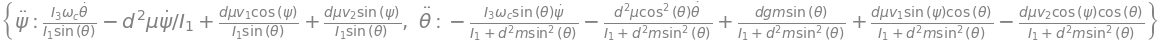

In [10]:
# obtain EOMs setting higher order terms equal zero
eq0=(LHS[0]-Trq_m[0]).xreplace({theta_dot**2:0,psi_dot**2:0})
# setting higher order terms equal zero (cos(theta) instead of psi_dot X theta_dot)
eq1=(LHS[1]-Trq_m[1]).xreplace({cos(theta):0})
sol=solve([eq0,eq1],[psi_ddot,theta_ddot])
sol

As for the equations of translational motion, entering (8) and (11) into (12) and considering horizontal elements, the following equations are obtained: 
$$
\begin{align}
m\dot{v}_1+\mu v_1 -d\mu(\sin\psi\cos\theta\,\dot{\theta}+\cos\psi\sin\theta\,\dot{\psi}) =& 0 \tag{20}\\
m\dot{v}_2+\mu v_2 +d\mu(\cos\psi\cos\theta\,\dot{\theta}-\sin\psi\sin\theta\,\dot{\psi}) =& 0 \tag{21}\\
\end{align}
$$

In [11]:
# translational equations
trl_eq=(m*VG.dt(N)-Kf).to_matrix(N)
VG_dot = solve([trl_eq[0], trl_eq[1]],[v1_dot, v2_dot])
VG_dot

Like in the example of rotating disk, $x_1$ and $x_2$ will be determined numerically with the following equations:
$$
\begin{align}
{x_i}(t+1) =& x_i(t)+ \Delta x_i(t)\\
           =& x_i(t)+ v_i(\psi,\theta,\dot{\psi},\dot{\theta},\dot{\phi},t),  \tag{22}                                                
\end{align}
$$  
where $i=1,2$ and $t$ stands for discrete time.

If we take a state vector  $\boldsymbol{y} = \left [ \dot{\psi}, \ \dot{\theta}, \ \dot{\phi} , \ \psi, \ \theta, \ \phi, \ v_{1}, \ v_{2}, \ x_{1}, \ x_{2} \right ]^{T}$, the whole set of equations can be expressed in a form $M(t,\boldsymbol{u})\dot{\boldsymbol{u}} =f(t,\boldsymbol{u})$ and rearranging it for $\dot{\boldsymbol{u}}$ we have:

$$\dot{\boldsymbol{u}} =M(t,\boldsymbol{u})^{-1}f(t,\boldsymbol{u}).\tag{23}$$
The details of the numerical solution should be clear in the the codes given below. Both physical parameters and initial conditions for the numerical integration are given in the cell [12]; "Lamdification" of the symbolic equations is done in the cell [13]; a function for the odeint solver is described in the cell [14]. The cells [15] to [17] provide codes for modelling and 3-D animation.

In [12]:
#  Physical parameters:
_r = 20/1000
_g = 9.81
_m=8/1000 #kg
_d=20/1000
_mu= 0.01
_I_1 = 1/4*_m*_r**2      # kg-m^2
_I_3 = 1/2*_m*_r**2      # kg-m^2

#Initial conditions
psi0 = 0*(np.pi/180)     # rad
theta0 = 15*(np.pi/180)  # rad
phi0 = 0                 # rad
thetadot0 = 0                     #  rad/s
phidot0 = 150                     # rad/s
psidot0 = _m*_g*_d/(_I_3*phidot0) #  rad/s 
x1d0=0.1           #  m/s
x2d0=0             #  m/s
x10 = 0            #  m
x20 = 0            #  m
omg_c=np.cos(theta0)*psidot0+phidot0

#  Simulation parameters:
tf = 8.5           #  s
dt = 0.03          #  s

In [13]:
# constant coefficent symbols replaced by numbers
psi_ddot_ = sol[psi_ddot].simplify().subs([(omega_c, omg_c),(d,_d,), (mu,_mu), (I_1,_I_1), (I_3,_I_3)])
theta_ddot_ =sol[theta_ddot].simplify().subs([(d,_d),(m,_m),(mu,_mu), (g,_g), (I_1,_I_1),(I_3,_I_3),(omega_c, omg_c)])
N_V_G_dot_0 = VG_dot[v1_dot].subs([(m,_m), (d,_d,), (mu,_mu)])
N_V_G_dot_1 = VG_dot[v2_dot].subs([(m,_m), (d,_d,), (mu,_mu)])

# lamdify the equations for numerical calculation
args_bdy = (psi, theta, psi_dot, theta_dot, v1, v2) # defining variables for lamdification
psi_ddot_f = lambdify(args_bdy, psi_ddot_, "numpy")
theta_ddot_f = lambdify(args_bdy, theta_ddot_, "numpy")
args_VG_dot0= (psi, theta, psi_dot, theta_dot, v1) 
args_VG_dot1= (psi, theta, psi_dot, theta_dot, v2) 
N_V_G_dot_x0_f=lambdify(args_VG_dot0, N_V_G_dot_0, "numpy")
N_V_G_dot_x1_f=lambdify(args_VG_dot1, N_V_G_dot_1, "numpy")

In [14]:
# Define a function for the odeint solver
def dSdt(S, t):
    psi_dot, theta_dot, psi, theta, v1, v2, x1, x2 = S
    return [
        psi_ddot_f(psi, theta, psi_dot, theta_dot, v1, v2),
        theta_ddot_f(psi, theta, psi_dot, theta_dot, v1, v2),
        psi_dot,
        theta_dot,
        N_V_G_dot_x0_f(psi, theta, psi_dot, theta_dot, v1),
        N_V_G_dot_x1_f(psi, theta, psi_dot, theta_dot, v2),
        v1,
        v2,
    ]
#initial conditions
Y0=[psidot0, thetadot0, psi0, theta0, x1d0,x2d0,x10,x20]
# time span
t = np.arange(0, tf, dt)
# solve the differential equation  
ans = odeint(dSdt, y0=Y0, t=t)
# give solved answers recognizable names
psidt_ =ans.T[0]
thetadt_ = ans.T[1]
psi_ = ans.T[2]
theta_ = ans.T[3]
v1_= ans.T[4]
v2_=ans.T[5]
x1_=ans.T[6]
x2_=ans.T[7]

In [15]:
# top's graphical configuration
G=Point('G') #mass center
P = G.locatenew('P', -_d*L.z) #Top's contact point defined relative to the mass center
cmt = 10/1000.0 # distance from center of mass to top's top
T=G.locatenew('T', cmt*L.z) #top's upper end
S0=G.locatenew('S0', _r*R.x) #top's spoke No.0
S1=G.locatenew('S1',_r*np.cos(2*np.pi/3)*R.x+_r*np.sin(2*np.pi/3)*R.y)  #top's spoke No.1
S2=G.locatenew('S2',_r*np.cos(-2*np.pi/3)*R.x+_r*np.sin(-2*np.pi/3)*R.y) #top's spoke No.2

In [16]:
# calculate the top's contact point coordinates
xp1 = x1_-_d*np.sin(theta_)*np.sin(psi_) # point P coordinate x
xp2 = x2_+_d*np.sin(theta_)*np.cos(psi_) # point P coordinate y

# calculate the top's rim point coordinates
rim = S0.pos_from(G).to_matrix(N)
rim_f = lambdify([psi,theta,phi], rim)

def calc_top_rim(x_, y_, z_, psi_,theta_): #x_,y_,z_: mass center
    top_rim_coords=[]
    #.express_coordinates(N)
    phi_s = np.linspace(0, 2*np.pi,18)
    for ph in phi_s:
        temp=rim_f(psi_,theta_,ph).T[0,:]+np.array([x_,y_,z_])
        top_rim_coords.append(temp)
    return top_rim_coords

# top's spining axis and spokes 
as_coords = G.pos_from(G).to_matrix(N)
for point in [P, T, S0, S1, S2]:
    as_coords = as_coords.row_join(point.pos_from(G).to_matrix(N))
_as_coords = as_coords.subs([[phi,phi0]]) # phi is constant
as_coords_f = lambdify([psi,theta], _as_coords)

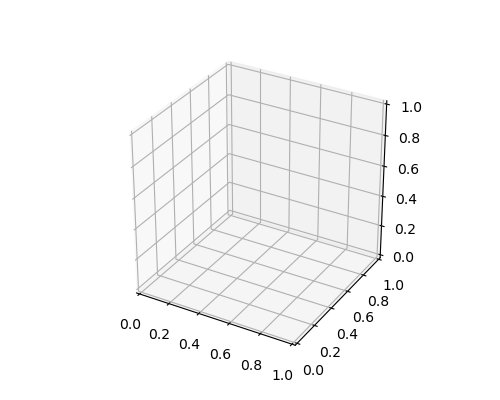

In [17]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, projection ='3d')
ax.set_box_aspect((1,1,1))
line_prop = {
    'color': 'black',
    'marker': 'o',
    'markerfacecolor': 'blue',
    'markersize': 2,
}
l=0.05

def animate(i):
    ax.cla()
    ax.set_xlim((0, 0.1))
    ax.set_ylim((-l, l))
    ax.set_zlim((0, 0.1))
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_zlabel('z [m]')
    
    x3c=_d*np.cos(theta_[i])
    temp=as_coords_f(psi_[i],theta_[i]).T+np.array([x1_[i], x2_[i], x3c])
    as_x, as_y, as_z = temp.T 
    ax.plot(xp1[:i], xp2[:i], 0, 'bo', markersize=0.5) # contact point
    ax.plot(as_x[0], as_y[0], as_z[0], 'ro', markersize=2) # mass center
    lines_3d,= ax.plot([as_x[1],as_x[2]], [as_y[1],as_y[2]], [as_z[1],as_z[2]], color="k", alpha=0.5)
    verts0 = calc_top_rim(ans[i,6], ans[i,7], _d*np.cos(ans[i,3]),ans[i,2],ans[i,3])
    ax.add_collection3d(Poly3DCollection([verts0],edgecolor='k', facecolor='#000080',alpha=0.5))
    lines_3d,= ax.plot([x1_[i],as_x[3]], [x2_[i],as_y[3]], [x3c,as_z[3]], color="k", alpha=0.5)
    lines_3d,= ax.plot([x1_[i],as_x[4]], [x2_[i],as_y[4]], [x3c,as_z[4]], color="k", alpha=0.5)
    lines_3d,= ax.plot([x1_[i],as_x[5]], [x2_[i],as_y[5]], [x3c,as_z[5]], color="k", alpha=0.5)
ani = FuncAnimation(fig, animate, len(t),interval=20)
#ani.save('poisson_top.gif', writer='pillow', fps=30)

# References
https://rotations.berkeley.edu/the-poisson-top-with-friction/